# Go NoGo Task - Auswertung

Das Experiment umfasste 60 Trials (45 go trails, 15 nogo trials). Es haben 14 Versuchspersonen teilgenommen.

In [63]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import ttest_ind as ttestind
from scipy.stats import ttest_rel as ttestrel
from scipy.stats import norm
import seaborn as sns

import statsmodels.api as sm
from scipy.optimize import curve_fit
import warnings
from IPython.display import display, HTML

### 1. Daten einlesen & Variablen vordefinieren

Passe den Pfad an und ergänze die Versuchspersonennummern.

In [2]:
# Pfad und Dateinamenskomponenten
path2load = r'C:\Users\sebas\Seminar Exercise\data_final'
filename = 'GoNoGo_'
postfix = '.csv'

# Teilnehmerliste als Strings
subs = ['01', '02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14']
# Füge weitere VPn hinzu. 

# Initialisierung eines 2D-Arrays mit zeros für die Ergebnisse. 
# Die Anzahl der Zeilen soll der Anzahl an Versuchspersonen entsprechen.
# Außerdem 4 Spalten haben:
# Spalten: 0 - correct hit, 1 - correct miss, 2 - false miss, 3 - false hit
master_results = np.array([[0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0], [0, 0, 0,0]])
print(master_results)

[[0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]
 [0 0 0 0]]


### 2. Files laden & Variablen befüllen

In diesem Teil sollten nun die eingelesen Daten entsprechend der Kategorien hits, misses, false hits und false misses eingeordnet werden. Dafür braucht es ein If-Statement, welches alle Trials überpruft und den Kategorien zuordnet. Am Ende sollten für alle VPn die Ergebnisse in "det Master Results" Matrix aufgeführt sein.

In [3]:
# Schleife über alle VPs

for i, sub in enumerate(subs):
    
    # CSV-Datei einlesen
    filepath = os.path.join(path2load, f'{filename}{sub}{postfix}')
    data = pd.read_csv(filepath) # Wir nutzen hier den read_csv Command aus dem panda-Package.

    # Nur relevante Splaten behalten & leere Zeilen entfernen:
    keep_columns = ['type', 'TrialResp.corr'] # Wir brauchen nur diese beiden Spalten.
    data = data[keep_columns]
    data = data.dropna(subset=['type']) # Aber wir wollen keine leeren Zeilen.

    
   # Durch jede Zeile in data gehen:
    for index, row in data.iterrows():
        
        trial_type = row['type'] 
        answer_correct = row['TrialResp.corr']

        # Hier wäre ein If-Statement hilfreich, dass je nach Art des Trials und Richtigkeit der Antwort
        # den Counter der entsprechenden Spalte in master_results erhöht.
        if trial_type == 'go' and answer_correct == 1:
         master_results [i, 0] += 1
        if trial_type == 'go' and answer_correct == 0:
         master_results [i, 1] += 1
        if trial_type == 'nogo' and answer_correct == 1:
         master_results [i, 2] += 1
        if trial_type == 'nogo' and answer_correct == 0:
         master_results [i, 3] += 1

# Lass dir die master_results Variable ausgeben:
print(master_results)

[[44  1 13  2]
 [44  1 12  3]
 [45  0 14  1]
 [45  0 14  1]
 [45  0 13  2]
 [45  0 12  3]
 [45  0 13  2]
 [44  1 15  0]
 [45  0 12  3]
 [43  2 12  3]
 [37  8  9  6]
 [35 10 11  4]
 [42  3  8  7]
 [32 13  7  8]]


### 3. Auswertung

#### Häufigkeiten & Verteilung

Schauen wir uns erstmal die Häufigkeiten der gegebenen Antworten und ihre Verteilung an. Erstelle dafür ein paar hübsche Plots (z.B. Balkendiagram, Boxplot...). Wurden mehr richtige oder mehr falsche Antworten gegeben? (Bedenke: Relativiert an der tatsächlichen Anzahl an möglichen richtigen und falschen Antworten.) Welche Fehlerart wurde eher gemacht? Was wäre noch interessant auszuwerten?

### Absolute Verteilung

[591  39 165  45]



<Figure size 640x480 with 0 Axes>

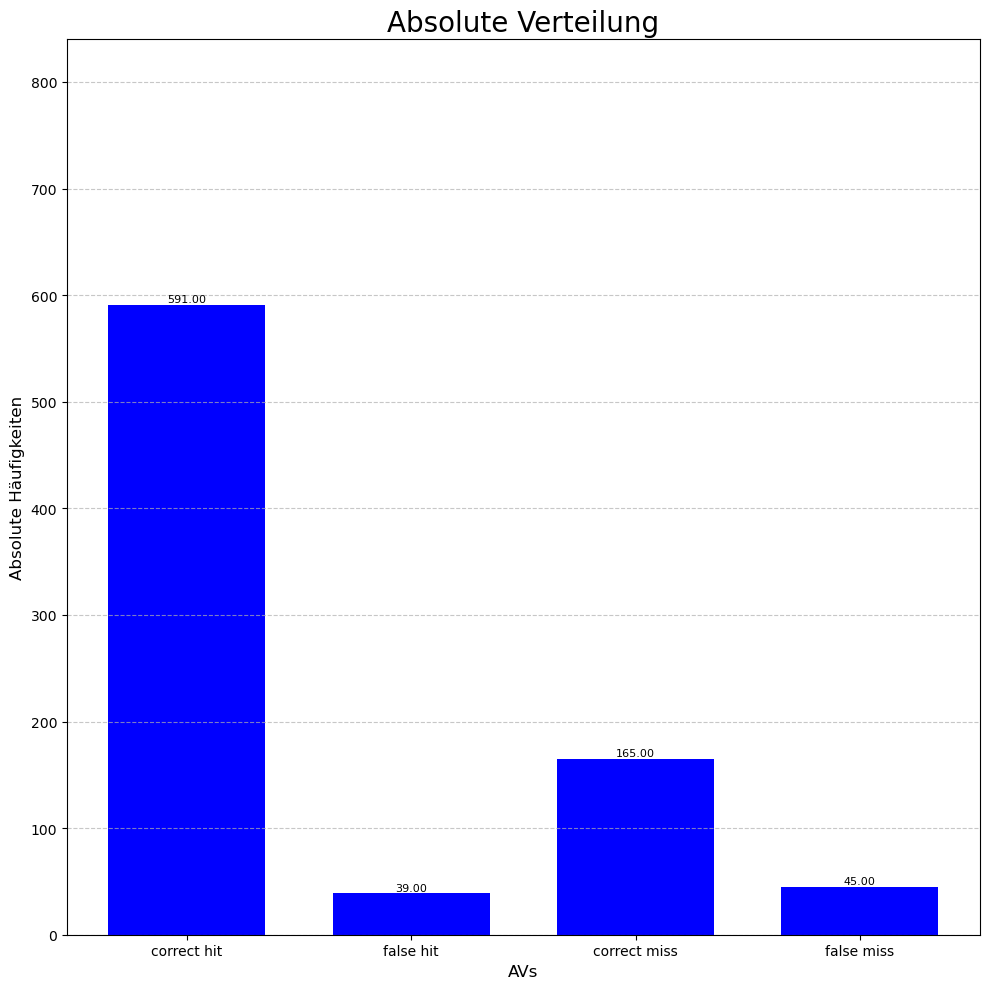

In [4]:
smr = np.sum(master_results, axis=0) # Summe der Reaktionen in den Spalten 
print(smr)
print()

plt.figure()
x = np.arange(len(smr)) # X-Achsen-Positionen: 0, 1, 2, 3 für 4 Spalten
h = smr 

plt.figure(figsize=(10,10))
plt.bar(x, h, color='blue', width=0.7)

plt.title('Absolute Verteilung', fontsize=20)
plt.xlabel('AVs', fontsize=12)
plt.ylabel('Absolute Häufigkeiten', fontsize=12)
plt.ylim(0, 14*60)

for i, smr in enumerate(smr):
    plt.text(x[i], smr + 0.50, f'{smr:.2f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x, ['correct hit', 'false hit', 'correct miss', 'false miss'], fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

### Relative Verteilung

[42.21428571  2.78571429 11.78571429  3.21428571]



<Figure size 640x480 with 0 Axes>

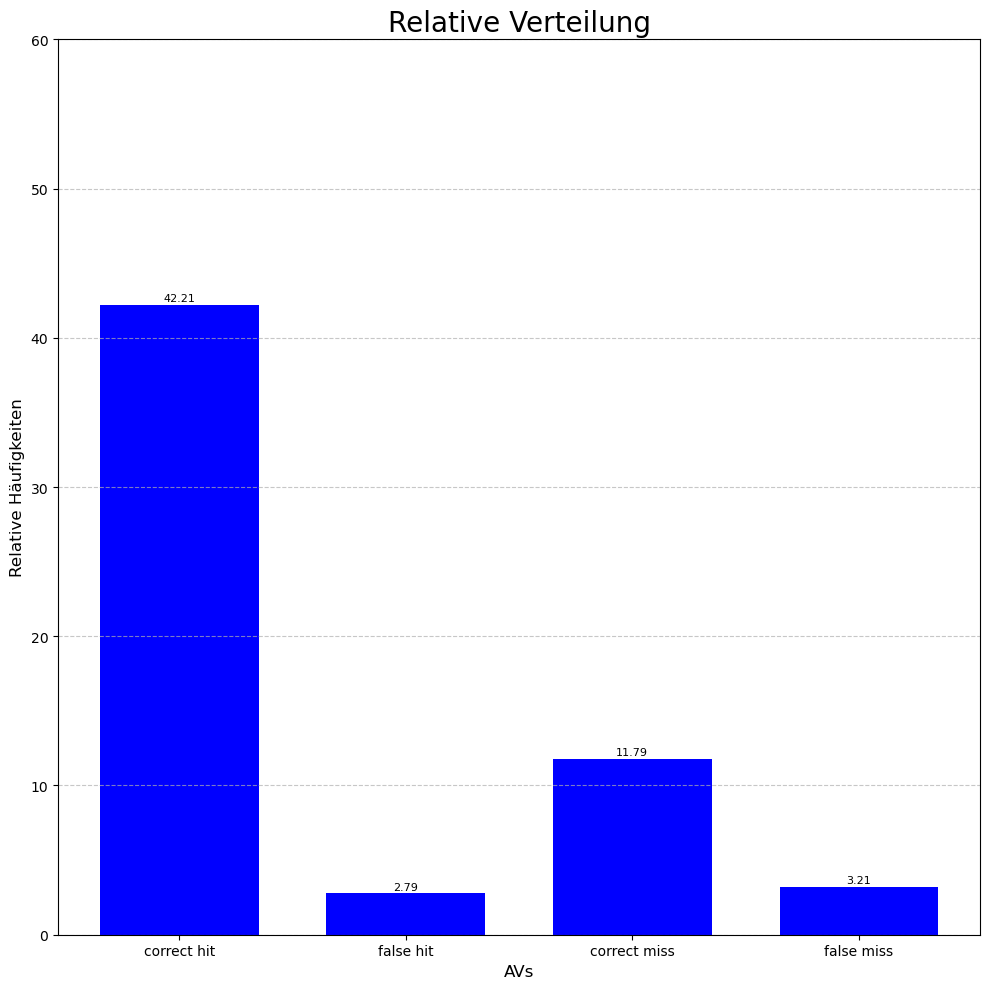

In [5]:
mmr = np.mean(master_results, axis=0)
print(mmr)
print()

plt.figure()
x = np.arange(len(mmr)) # X-Achsen-Positionen: 0, 1, 2, 3 für 4 Spalten
heights = mmr 

plt.figure(figsize=(10,10))
plt.bar(x, heights, color='blue', width=0.7)

plt.title('Relative Verteilung', fontsize=20)
plt.xlabel('AVs', fontsize=12)
plt.ylabel('Relative Häufigkeiten', fontsize=12)
plt.ylim(0, 60)

for i, height in enumerate(heights):
    plt.text(x[i], height + 0.10, f'{height:.2f}', ha='center', va='bottom', fontsize=8)

plt.xticks(x, ['correct hit', 'false hit', 'correct miss', 'false miss'], fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

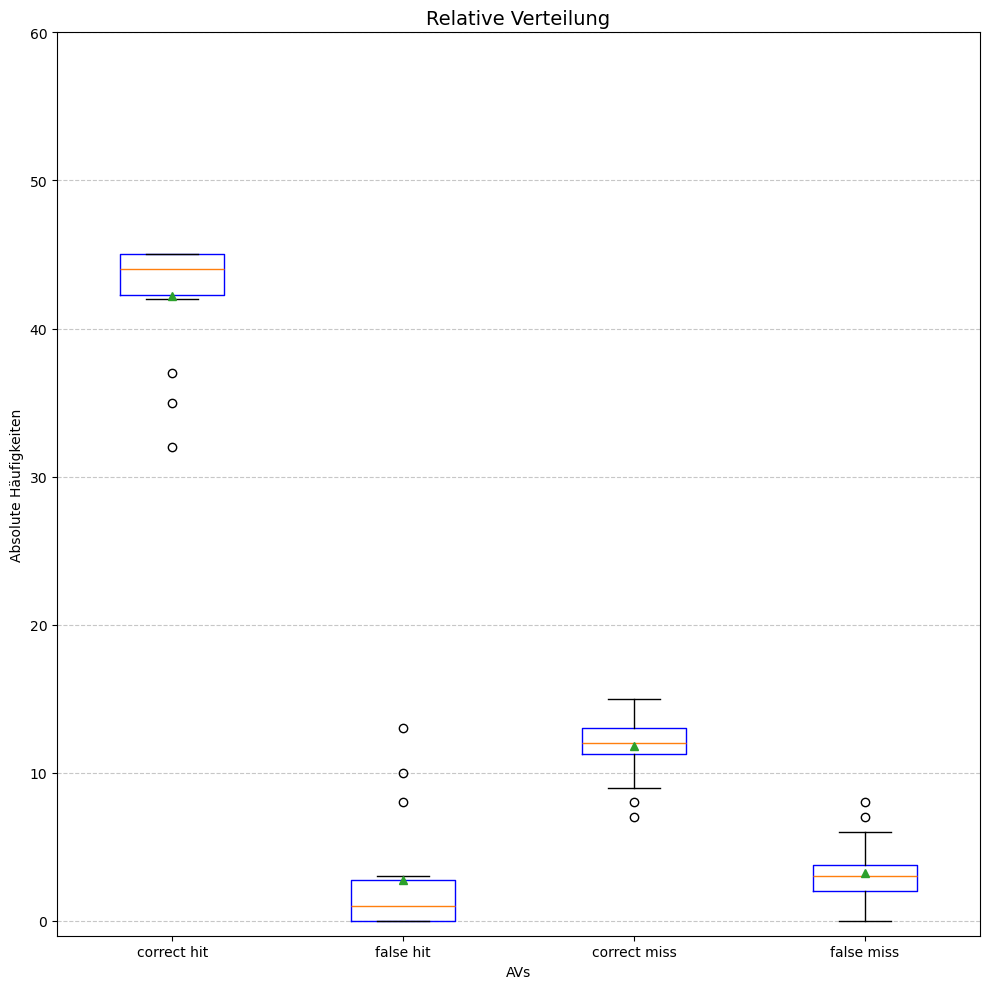

In [6]:
plt.figure()

data1 = master_results[:, 0]
data2 = master_results[:, 1]
data3 = master_results[:, 2]
data4 = master_results[:, 3]

data = [data1, data2, data3, data4]
label = ['correct hit', 'false hit', 'correct miss', 'false miss']

plt.figure(figsize=(10,10))
plt.boxplot(data, tick_labels = label, showmeans = True, boxprops = dict(color = "blue"))

plt.title('Relative Verteilung', fontsize=14)
plt.xlabel('AVs', fontsize=10)
plt.ylabel('Absolute Häufigkeiten', fontsize=10)
plt.ylim(-1, 60)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

### Gewichtet an der maximalen Anzahl möglic

[42.21428571  2.78571429 11.78571429  3.21428571]

[0.93809524 0.06190476 0.78571429 0.21428571]



<Figure size 640x480 with 0 Axes>

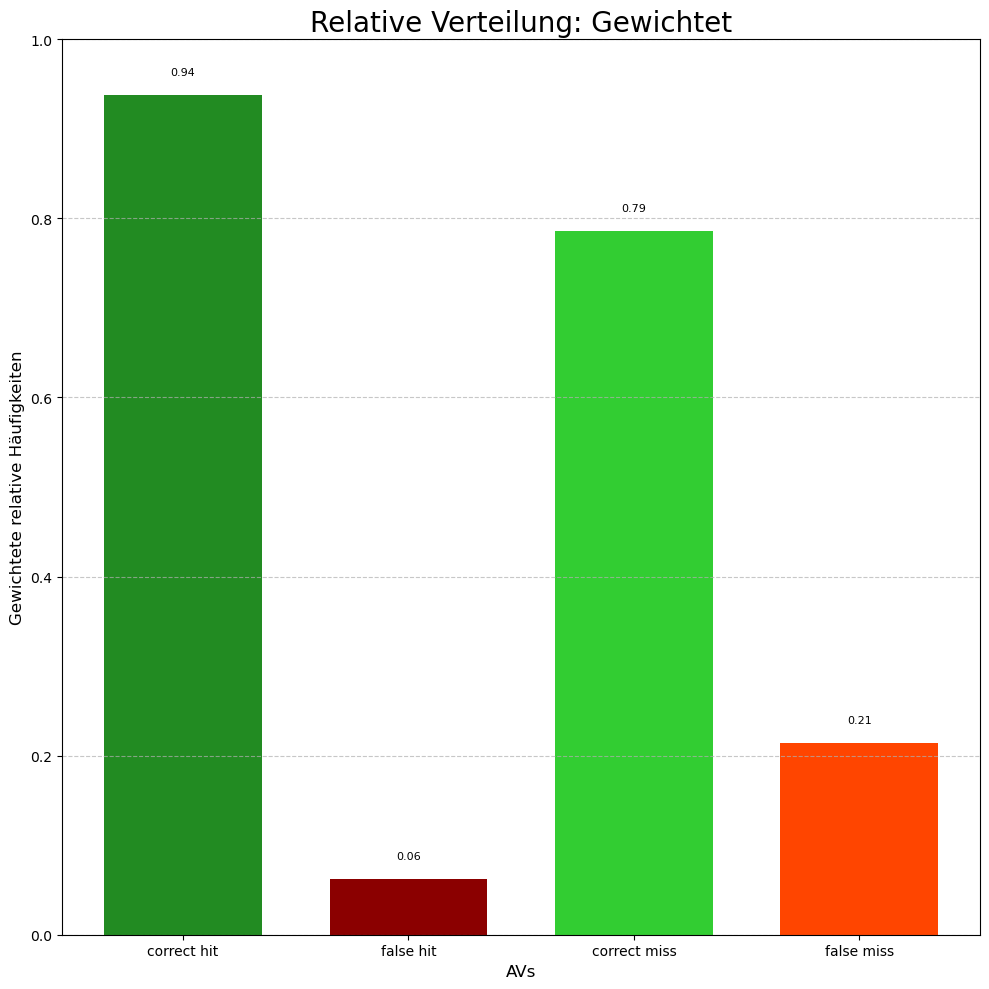

In [7]:
mmr = np.mean(master_results, axis=0)
print(mmr)
print()

pm = np.array([
    45, # Max für 'correct hit'
    45, # Max für 'false hit'
    15, # Max für 'correct miss'
    15  # Max für 'false miss'
])

nmmr = mmr / pm
print(nmmr)
print()

plt.figure()
x = np.arange(len(nmmr)) # X-Achsen-Positionen: 0, 1, 2, 3 für 4 Spalten
heights = nmmr 

plt.figure(figsize=(10,10))
plt.bar(x, heights, color=['forestgreen', 'darkred', 'limegreen', 'orangered'], width=0.7)

plt.title('Relative Verteilung: Gewichtet', fontsize=20)
plt.xlabel('AVs', fontsize=12)
plt.ylabel('Gewichtete relative Häufigkeiten', fontsize=12)
# Y-Achsen-Grenzen auf 0 bis 1 setzen, da es sich um Anteile handelt
plt.ylim(0, 1)

# Optional: Textbeschriftungen über den Balken für die genauen Werte (Gemini)
for i, height in enumerate(heights):
    plt.text(x[i], height + 0.02, f'{height:.2f}', ha='center', va='bottom', fontsize=8)


plt.xticks(x, ['correct hit', 'false hit', 'correct miss', 'false miss'], fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

#### Treffer- und Fehlerrate

Als nächstes sollen die Treffer- und Fehlerquoten berechnet werden.
Berechne diese zunächst für jede Versuchsperson (Stichwort: Loop) und berechne dann die Mittelwerte der Gruppe.

Reminder: <br>
accuracy   = (hits + correct rejections) / no. of trials<br>
error rate = (misses + false positives) / no. of trials<br>

Frage: <br>
Waren die 36 ein Tippfehler (von der ursprünglichen Angabe 66)?

In [8]:
print(master_results)
print()

print('correct hits', master_results[:, 0])
print('false hits', master_results[:, 1])
print('correct misses', master_results[:, 2])
print('false misses', master_results[:, 3])
print() 

part = master_results.shape[0] # also Anzahl der Zeilen, ergo der Versuchspersonen (14)
trials = 60 

print('-'*100)
display(HTML("<div style='text-align: center;'>--- Personenmittelwerte --- </div>"))
print()

# Dictionaries zum Speichern der Ergebnisse pro Versuchsperson
accuracy_per_person = {}
error_rate_per_person = {}

# Loop durch jede Versuchsperson
for i in range(part):
    # Generiere den Key für das Dictionary; "VP 01", "VP 02", ...
    # ':02d' formatiert die Zahl mit einer führenden Null, falls sie einstellig ist (z.B. 1 = 01)
    participant_key = f"VP {i+1:02d}"

    # Zählungen für die aktuelle Versuchsperson
    correct_hit = master_results[i, 0] # hits
    false_hit = master_results[i, 1] # false positives
    correct_miss = master_results[i, 2] # correct rejection
    false_miss = master_results[i, 3]   # misses

    # Berechnung der Accuracy für die aktuelle Versuchsperson
    current_accuracy = (correct_hit + correct_miss) / trials
    # Wert zum Dictionary hinzufügen
    accuracy_per_person[participant_key] = current_accuracy

    # Berechnung der Error Rate für die aktuelle Versuchsperson
    current_error_rate = (false_miss + false_hit) / trials
    # Wert zum Dictionary hinzufügen
    error_rate_per_person[participant_key] = current_error_rate

print("Accuracy pro Versuchsperson:")
print(accuracy_per_person)
print()
print("Error Rate pro Versuchsperson:")
print(error_rate_per_person)
print()

print('-'*100)
display(HTML("<div style='text-align: center;'>--- Gruppenmittelwerte --- </div>"))
print()

group_mean_accuracy = np.mean(list(accuracy_per_person.values()))
group_mean_error_rate = np.mean(list(error_rate_per_person.values()))

print(f"Gruppen-Mittelwert Accuracy: {group_mean_accuracy:.2f}")
print(f"Gruppen-Mittelwert Error Rate: {group_mean_error_rate:.2f}")

[[44  1 13  2]
 [44  1 12  3]
 [45  0 14  1]
 [45  0 14  1]
 [45  0 13  2]
 [45  0 12  3]
 [45  0 13  2]
 [44  1 15  0]
 [45  0 12  3]
 [43  2 12  3]
 [37  8  9  6]
 [35 10 11  4]
 [42  3  8  7]
 [32 13  7  8]]

correct hits [44 44 45 45 45 45 45 44 45 43 37 35 42 32]
false hits [ 1  1  0  0  0  0  0  1  0  2  8 10  3 13]
correct misses [13 12 14 14 13 12 13 15 12 12  9 11  8  7]
false misses [2 3 1 1 2 3 2 0 3 3 6 4 7 8]

----------------------------------------------------------------------------------------------------



Accuracy pro Versuchsperson:
{'VP 01': 0.95, 'VP 02': 0.9333333333333333, 'VP 03': 0.9833333333333333, 'VP 04': 0.9833333333333333, 'VP 05': 0.9666666666666667, 'VP 06': 0.95, 'VP 07': 0.9666666666666667, 'VP 08': 0.9833333333333333, 'VP 09': 0.95, 'VP 10': 0.9166666666666666, 'VP 11': 0.7666666666666667, 'VP 12': 0.7666666666666667, 'VP 13': 0.8333333333333334, 'VP 14': 0.65}

Error Rate pro Versuchsperson:
{'VP 01': 0.05, 'VP 02': 0.06666666666666667, 'VP 03': 0.016666666666666666, 'VP 04': 0.016666666666666666, 'VP 05': 0.03333333333333333, 'VP 06': 0.05, 'VP 07': 0.03333333333333333, 'VP 08': 0.016666666666666666, 'VP 09': 0.05, 'VP 10': 0.08333333333333333, 'VP 11': 0.23333333333333334, 'VP 12': 0.23333333333333334, 'VP 13': 0.16666666666666666, 'VP 14': 0.35}

----------------------------------------------------------------------------------------------------



Gruppen-Mittelwert Accuracy: 0.90
Gruppen-Mittelwert Error Rate: 0.10


## ROC-Kurve
#### nicht von mir selbst gemacht und nur angefügt zur Visualisierung

TPR pro Versuchsperson: [0.9565217391304348, 0.9361702127659575, 0.9782608695652174, 0.9782608695652174, 0.9574468085106383, 0.9375, 0.9574468085106383, 1.0, 0.9375, 0.9347826086956522, 0.8604651162790697, 0.8974358974358975, 0.8571428571428571, 0.8]

FPR pro Versuchsperson: [0.07142857142857142, 0.07692307692307693, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0625, 0.0, 0.14285714285714285, 0.47058823529411764, 0.47619047619047616, 0.2727272727272727, 0.65]

----------------------------------------------------------------------------------------------------


Logistic function parameters: L=59.415, k=0.663, x0=-7.080, b=-58.174


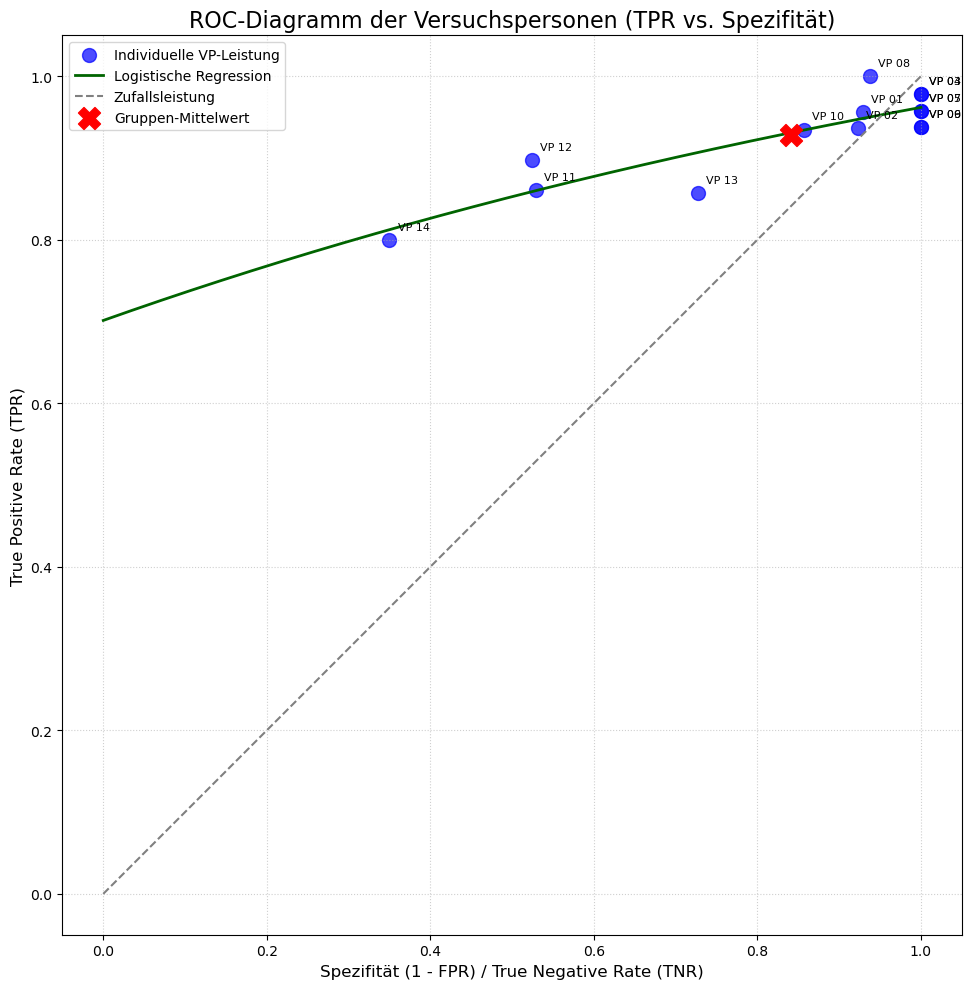

In [9]:
part = master_results.shape[0] # Anzahl der Versuchspersonen (14)
trials = 60 

# Listen zum Speichern der TPR und FPR für jede Versuchsperson
tpr_per_person = []
fpr_per_person = []

# Loop durch jede Versuchsperson
for i in range(part):
    correct_hit = master_results[i, 0] # hits
    false_hit = master_results[i, 1] # false positives
    correct_miss = master_results[i, 2] # correct rejection
    false_miss = master_results[i, 3]   # missess'

    # Denominatoren für TPR und FPR
    # total_target_present_trials = correct_hit + false_miss (sollte 45 sein)
    # total_target_absent_trials = false_hit + correct_miss (sollte 15 sein)

    # Berechnung von TPR und FPR für die aktuelle Versuchsperson
    # Vermeide Division durch Null, falls ein Nenner 0 sein sollte (unwahrscheinlich bei diesem Setup)
    if (correct_hit + false_miss) > 0:
        current_tpr = correct_hit / (correct_hit + false_miss)
    else:
        current_tpr = 0 # Oder np.nan, je nach gewünschtem Verhalten bei 0 TP trials

    if (false_hit + correct_miss) > 0:
        current_fpr = false_hit / (false_hit + correct_miss)
    else:
        current_fpr = 0 # Oder np.nan, je nach gewünschtem Verhalten bei 0 TA trials

    tpr_per_person.append(current_tpr)
    fpr_per_person.append(current_fpr)

print(f"TPR pro Versuchsperson: {tpr_per_person}")
print()
print(f"FPR pro Versuchsperson: {fpr_per_person}")
print()

print('-'*100)
display(HTML("<div style='text-align: center;'>--- Plot --- </div>"))

plt.figure(figsize=(10, 10))

# Suppress warnings
warnings.filterwarnings("ignore")

# Assuming fpr_per_person and tpr_per_person are lists of values
fpr_per_person = np.array(fpr_per_person)  # Convert to numpy array
tpr_per_person = np.array(tpr_per_person)  # Convert tpr to numpy array too

# Check for and remove any NaN or infinite values
valid_indices = np.isfinite(fpr_per_person) & np.isfinite(tpr_per_person)
fpr_per_person = fpr_per_person[valid_indices]
tpr_per_person = tpr_per_person[valid_indices]

tnr_per_person = 1 - fpr_per_person  # Now this will work with numpy's broadcasting

# 1. Plotten der individuellen (1-FPR, TPR) Punkte als Scatter
plt.scatter(tnr_per_person, tpr_per_person, color='blue', s=100, alpha=0.7, label='Individuelle VP-Leistung')

# Optional: Nummerierung der Punkte
for i, (tnr, tpr) in enumerate(zip(tnr_per_person, tpr_per_person)):
    plt.text(tnr + 0.01, tpr + 0.01, f'VP {i+1:02d}', fontsize=8, ha='left', va='bottom')

# 2. Logistic regression
# Define the logistic function
def logistic_function(x, L, k, x0, b):
    """
    Logistic function with parameters:
    L: the curve's maximum value
    k: the steepness of the curve
    x0: the x-value of the sigmoid's midpoint
    b: the y-offset
    """
    return L / (1 + np.exp(-k * (x - x0))) + b

# Initial parameter guesses
p0 = [1.0, 10.0, 0.5, 0.0]  # [L, k, x0, b]

try:
    # Fit the logistic function to the data
    params, _ = curve_fit(logistic_function, tnr_per_person, tpr_per_person, p0=p0, maxfev=10000)
    
    # Create smooth x values for the entire plot range
    x_smooth = np.linspace(0, 1, 1000)
    
    # Calculate the fitted y values
    y_fit = logistic_function(x_smooth, *params)
    
    # Ensure y values stay within [0,1] range
    y_fit = np.clip(y_fit, 0, 1)
    
    # Plot the logistic regression curve
    plt.plot(x_smooth, y_fit, color='darkgreen', linestyle='-', linewidth=2, 
             label='Logistische Regression')
             
    # Optionally print the parameters
    L, k, x0, b = params
    print(f"Logistic function parameters: L={L:.3f}, k={k:.3f}, x0={x0:.3f}, b={b:.3f}")
    
except Exception as e:
    print(f"Logistic fit failed: {e}. Falling back to polynomial fit.")
    # Fallback to polynomial fit
    coeffs = np.polyfit(tnr_per_person, tpr_per_person, 3)
    poly_func = np.poly1d(coeffs)
    x_smooth = np.linspace(0, 1, 100)
    y_fit = np.clip(poly_func(x_smooth), 0, 1)  # Clip to [0,1]
    plt.plot(x_smooth, y_fit, color='darkgreen', linestyle='-', linewidth=2, 
             label='Polynomial Regression (Fallback)')

# 3. Plotten der Diagonalen (Zufallsleistung)
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Zufallsleistung')

# 4. Plotten des Gruppenmittelwerts
mean_tpr = np.mean(tpr_per_person)
mean_tnr = np.mean(tnr_per_person)
plt.scatter(mean_tnr, mean_tpr, color='red', marker='X', s=250, label='Gruppen-Mittelwert', zorder=5)

# 5. Diagramm-Beschriftungen und Titel
plt.title('ROC-Diagramm der Versuchspersonen (TPR vs. Spezifität)', fontsize=16)
plt.xlabel('Spezifität (1 - FPR) / True Negative Rate (TNR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.xlim(-0.05, 1.05)
plt.ylim(-0.05, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=10)
plt.gca().set_aspect('equal', adjustable='box')  # Gleiche Achsenskalierung

plt.tight_layout()
plt.show()

#### Signaldetektion

Sensitivität dprime berechnen.

d' = z(correct) - z(false)<br>


Hilfe:
* Befehl für die z-Transformtion: norm.ppf
* bei Extremwerten der Rate (d.h. 0 und 1) sind hohe bzw. niedrige z-Werte (z.B. 3/-3) angemessen

Wie könnte man die Verteilung der d'-Werte darstellen?

In [10]:
go_trials = 45 
nogo_trials = 15 

d_prime_per_person = [] 

for i in range(part):
    correct_hit = master_results[i, 0]
    false_hit = master_results[i, 1]

    # 1. Hit Rate (HR) und False Alarm Rate (FAR) berechnen
    hit_rate = correct_hit / go_trials
    false_alarm_rate = false_hit / nogo_trials

    # 2. Anpassung der Raten bei Extremwerten (0 oder 1)
    hr_adjusted = hit_rate
    if hit_rate == 1:
        hr_adjusted = 1 - 1 / (2 * go_trials)
    elif hit_rate == 0:
        hr_adjusted = 1 / (2 * go_trials)

    far_adjusted = false_alarm_rate
    if false_alarm_rate == 1:
        far_adjusted = 1 - 1 / (2 * nogo_trials)
    elif false_alarm_rate == 0:
        far_adjusted = 1 / (2 * nogo_trials)

    # 3. Z-Transformation anwenden
    z_hr = norm.ppf(hr_adjusted)
    z_far = norm.ppf(far_adjusted)

    # 4. d' berechnen
    d_prime = z_hr - z_far
    d_prime_per_person.append(d_prime)

print("d'-Werte pro Versuchsperson:")
for i, d_p in enumerate(d_prime_per_person):
    print(f"VP {i+1:02d}: {d_p:.4f}")

print()
print(f"Gruppen-Mittelwert d': {np.mean(d_prime_per_person):.4f}")

Berechnete d'-Werte pro Versuchsperson:
VP 01: 3.5110
VP 02: 3.5110
VP 03: 4.1205
VP 04: 4.1205
VP 05: 4.1205
VP 06: 4.1205
VP 07: 4.1205
VP 08: 3.5110
VP 09: 4.1205
VP 10: 2.8121
VP 11: 0.8402
VP 12: 0.3340
VP 13: 2.3427
VP 14: -0.5541

Gruppen-Mittelwert d': 2.9307


#### Balkendiagramm der d'-Werte pro Versuchsperson 

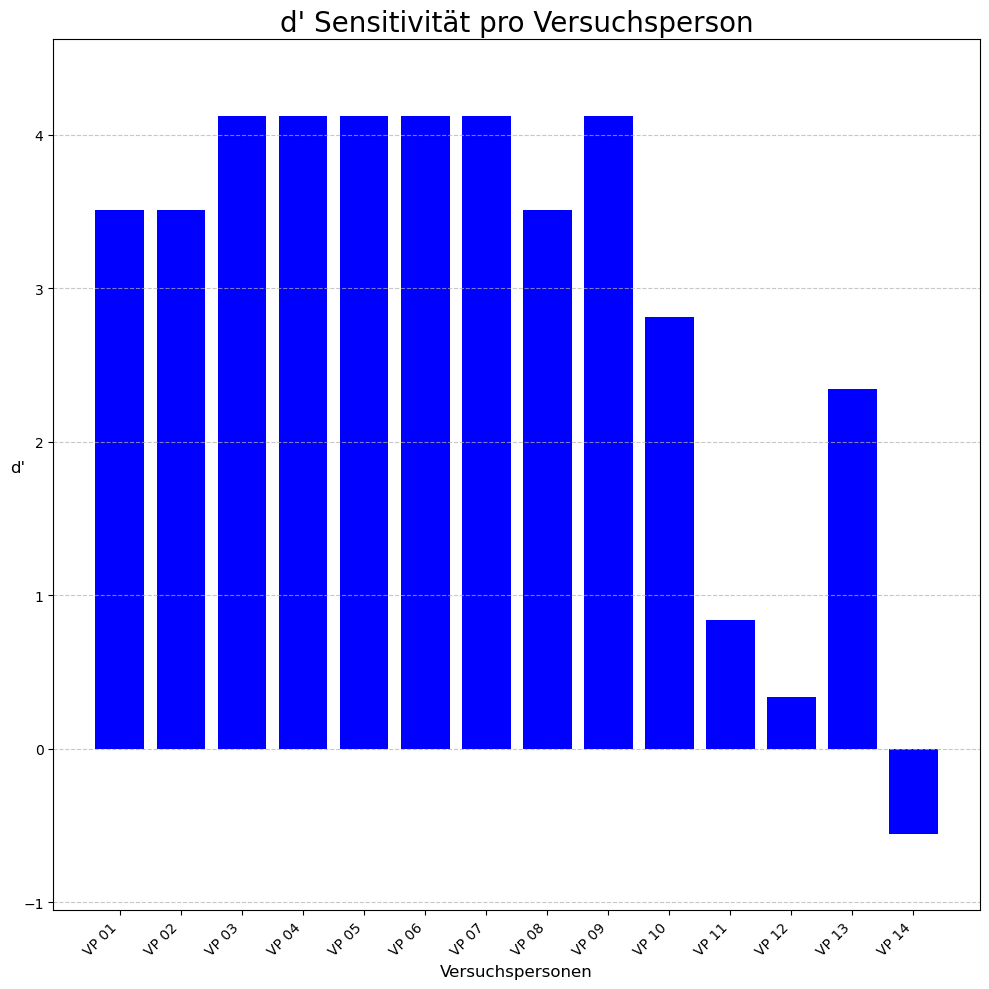

In [11]:
plt.figure(figsize=(10, 10))

# Labels für die X-Achse (VP 01, VP 02, ...)
participant_labels = [f"VP {i+1:02d}" for i in range(part)]

plt.bar(participant_labels, d_prime_per_person, color='blue')

plt.title("d' Sensitivität pro Versuchsperson", fontsize=20)
plt.xlabel("Versuchspersonen", fontsize=12)
plt.ylabel("d'", rotation=0, fontsize=12)

# Dynamische Gernezen der Y-Achsen
min_d = min(0, min(d_prime_per_person)) # startet bei 0 oder dem niedrigsten d'
max_d = max(d_prime_per_person)
plt.ylim(min_d - 0.5, max_d + 0.5) # etwas Puffer 

# Füge ein Gitter hinzu
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.xticks(rotation=45, ha='right', fontsize=10)

plt.tight_layout()
plt.show()

## Optional:

Wer möchte, kann die demografischen Daten aus den Folien verwenden, um Gruppenvergleiche (z.B. nach Geschlecht) oder Korrelationen (z.B. mit Alter) zu berechnen.

| VP| Geschlecht| Alter|
----------:|----------:|----------:|
|  1|       W   |    24| 
|  2|       W   |    19| 
|  3|       W   |    25| 
|  4|       W   |    21| 
|  5|       W   |    20| 
|  6|       W   |    20|
|  7|       W   |    22| 
|  8|       M   |    23| 
|  9|       M   |    18| 
| 10|       M   |    26| 
| 11|       M   |    22| 
| 12|       M   |    20| 
| 13|       M   |    21| 
| 14|       M   |    25|  

#### Vorbereitung der Daten

In [18]:
# Listen für Daten erstellen
performance_df = pd.DataFrame([
    {'vp_id': 'VP01', 'cor_hits': 44, 'fal_hits': 1, 'cor_miss': 13, 'fal_miss': 2},
    {'vp_id': 'VP02', 'cor_hits': 44, 'fal_hits': 1, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP03', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 14, 'fal_miss': 1},
    {'vp_id': 'VP04', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 14, 'fal_miss': 1},
    {'vp_id': 'VP05', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 13, 'fal_miss': 2},
    {'vp_id': 'VP06', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP07', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 13, 'fal_miss': 2},
    {'vp_id': 'VP08', 'cor_hits': 44, 'fal_hits': 1, 'cor_miss': 15, 'fal_miss': 0},
    {'vp_id': 'VP09', 'cor_hits': 45, 'fal_hits': 0, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP10', 'cor_hits': 43, 'fal_hits': 2, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP11', 'cor_hits': 37, 'fal_hits': 8, 'cor_miss': 9, 'fal_miss': 6},
    {'vp_id': 'VP12', 'cor_hits': 35, 'fal_hits': 10, 'cor_miss': 11, 'fal_miss': 4},
    {'vp_id': 'VP13', 'cor_hits': 42, 'fal_hits': 3, 'cor_miss': 8, 'fal_miss': 7},
    {'vp_id': 'VP14', 'cor_hits': 32, 'fal_hits': 13, 'cor_miss': 7, 'fal_miss': 8},
])

demographic_df = pd.DataFrame([
    {'vp_id': 'VP01', 'age': 24, 'gender': 'weiblich'},
    {'vp_id': 'VP02', 'age': 19, 'gender': 'weiblich'},
    {'vp_id': 'VP03', 'age': 25, 'gender': 'weiblich'},
    {'vp_id': 'VP04', 'age': 21, 'gender': 'weiblich'},
    {'vp_id': 'VP05', 'age': 20, 'gender': 'weiblich'},
    {'vp_id': 'VP06', 'age': 20, 'gender': 'weiblich'},
    {'vp_id': 'VP07', 'age': 22, 'gender': 'weiblich'},
    {'vp_id': 'VP08', 'age': 23, 'gender': 'männlich'},
    {'vp_id': 'VP09', 'age': 18, 'gender': 'männlich'},
    {'vp_id': 'VP10', 'age': 26, 'gender': 'männlich'},
    {'vp_id': 'VP11', 'age': 22, 'gender': 'männlich'},
    {'vp_id': 'VP12', 'age': 20, 'gender': 'männlich'},
    {'vp_id': 'VP13', 'age': 21, 'gender': 'männlich'},
    {'vp_id': 'VP14', 'age': 25, 'gender': 'männlich'},
])

print("Leistungsdaten:")
print(performance_df)
print()
print("Demographische Daten:")
print(demographic_df)
print()

# Zusammenführen der Daten - 'on' gibt die Spalte an, die als gemeinsame ID dient - 'how' gibt an, wie die Daten zusammengeführt werden sollen (z.B. 'inner' für nur passende IDs)
combined_df = pd.merge(performance_df, demographic_df, on='vp_id', how='inner')

print("Kombinierte Daten:")
print(combined_df)
print()

# Zugriff auf Daten 
print(combined_df['cor_hits'])
print(combined_df['fal_hits'])
print(combined_df['cor_miss'])
print(combined_df['fal_miss'])
print(combined_df['age'])
print(combined_df['gender'])

Leistungsdaten:
   vp_id  cor_hits  fal_hits  cor_miss  fal_miss
0   VP01        44         1        13         2
1   VP02        44         1        12         3
2   VP03        45         0        14         1
3   VP04        45         0        14         1
4   VP05        45         0        13         2
5   VP06        45         0        12         3
6   VP07        45         0        13         2
7   VP08        44         1        15         0
8   VP09        45         0        12         3
9   VP10        43         2        12         3
10  VP11        37         8         9         6
11  VP12        35        10        11         4
12  VP13        42         3         8         7
13  VP14        32        13         7         8

Demographische Daten:
   vp_id  age    gender
0   VP01   24  weiblich
1   VP02   19  weiblich
2   VP03   25  weiblich
3   VP04   21  weiblich
4   VP05   20  weiblich
5   VP06   20  weiblich
6   VP07   22  weiblich
7   VP08   23  männlich
8   VP09  

#### Geschlechter

In [64]:
# DataFrame.groupby('Spalte zum Gruppieren')['Spalte zum Mittelwertbilden'].mean()
a = combined_df.groupby('gender')['cor_hits'].mean()
b = combined_df.groupby('gender')['cor_hits'].min()
c = combined_df.groupby('gender')['cor_hits'].max()
d = combined_df.groupby('gender')['cor_hits'].agg(Range=np.ptp)
e = combined_df.groupby('gender')['cor_hits'].var()
f = combined_df.groupby('gender')['cor_hits'].std()
print("Mittelwertsunterschiede:", a)
print("Minimum:", b)
print("Maximum:", c)
print("Range:", d)
print("Varianz:", e)
print("Standardabweichung:", f)
print()

aI = combined_df.groupby('gender')['fal_hits'].mean()
bI= combined_df.groupby('gender')['fal_hits'].min()
cI = combined_df.groupby('gender')['fal_hits'].max()
dI = combined_df.groupby('gender')['fal_hits'].agg(Range=np.ptp)
eI = combined_df.groupby('gender')['fal_hits'].var()
fI = combined_df.groupby('gender')['fal_hits'].std()
print("Mittelwertsunterschiede:", aI)
print("Minimum:", bI)
print("Maximum:", cI)
print("Range:", dI)
print("Varianz:", eI)
print("Standardabweichung:", fI)
print()

aII = combined_df.groupby('gender')['cor_miss'].mean()
bII = combined_df.groupby('gender')['cor_miss'].min()
cII = combined_df.groupby('gender')['cor_miss'].max()
dII = combined_df.groupby('gender')['cor_miss'].agg(Range=np.ptp)
eII = combined_df.groupby('gender')['cor_miss'].var()
fII = combined_df.groupby('gender')['cor_miss'].std()
print("Mittelwertsunterschiede:", aII)
print("Minimum:", bII)
print("Maximum:", cII)
print("Range:", dII)
print("Varianz:", eII)
print("Standardabweichung:", fII)
print()

aIII = combined_df.groupby('gender')['fal_miss'].mean()
bIII = combined_df.groupby('gender')['fal_miss'].min()
cIII = combined_df.groupby('gender')['fal_miss'].max()
dIII = combined_df.groupby('gender')['fal_miss'].agg(Range=np.ptp)
eIII = combined_df.groupby('gender')['fal_miss'].var()
fIII = combined_df.groupby('gender')['fal_miss'].std()
print("Mittelwertsunterschiede:", aIII)
print("Minimum:", bIII)
print("Maximum:", cIII)
print("Range:", dIII)
print("Varianz:", eIII)
print("Standardabweichung:", fIII)
print()

# T-Test für Mittelwertsunterschiede in Correct Hits als Beispiel: T-Test für "unabhängige" Gruppen
testvar = 'cor_hits' 
ma = combined_df[combined_df['gender'] == 'männlich'][testvar]
fe = combined_df[combined_df['gender'] == 'weiblich'][testvar]

t, p = ttestind(ma, fe, equal_var=True)

print(f"Variable: {testvar}")
print(f"\nT-Statistik: {t:.3f}")
print(f"P-Wert: {p:.3f}")

Mittelwertsunterschiede: gender
männlich    39.714286
weiblich    44.714286
Name: cor_hits, dtype: float64
Minimum: gender
männlich    32
weiblich    44
Name: cor_hits, dtype: int64
Maximum: gender
männlich    45
weiblich    45
Name: cor_hits, dtype: int64
Range:           Range
gender         
männlich     13
weiblich      1
Varianz: gender
männlich    25.238095
weiblich     0.238095
Name: cor_hits, dtype: float64
Standardabweichung: gender
männlich    5.023753
weiblich    0.487950
Name: cor_hits, dtype: float64

Mittelwertsunterschiede: gender
männlich    5.285714
weiblich    0.285714
Name: fal_hits, dtype: float64
Minimum: gender
männlich    0
weiblich    0
Name: fal_hits, dtype: int64
Maximum: gender
männlich    13
weiblich     1
Name: fal_hits, dtype: int64
Range:           Range
gender         
männlich     13
weiblich      1
Varianz: gender
männlich    25.238095
weiblich     0.238095
Name: fal_hits, dtype: float64
Standardabweichung: gender
männlich    5.023753
weiblich    0.487

##### Plot für die Verläufe der Werte nach Geschlechtern (Beispiel Correct Hits)

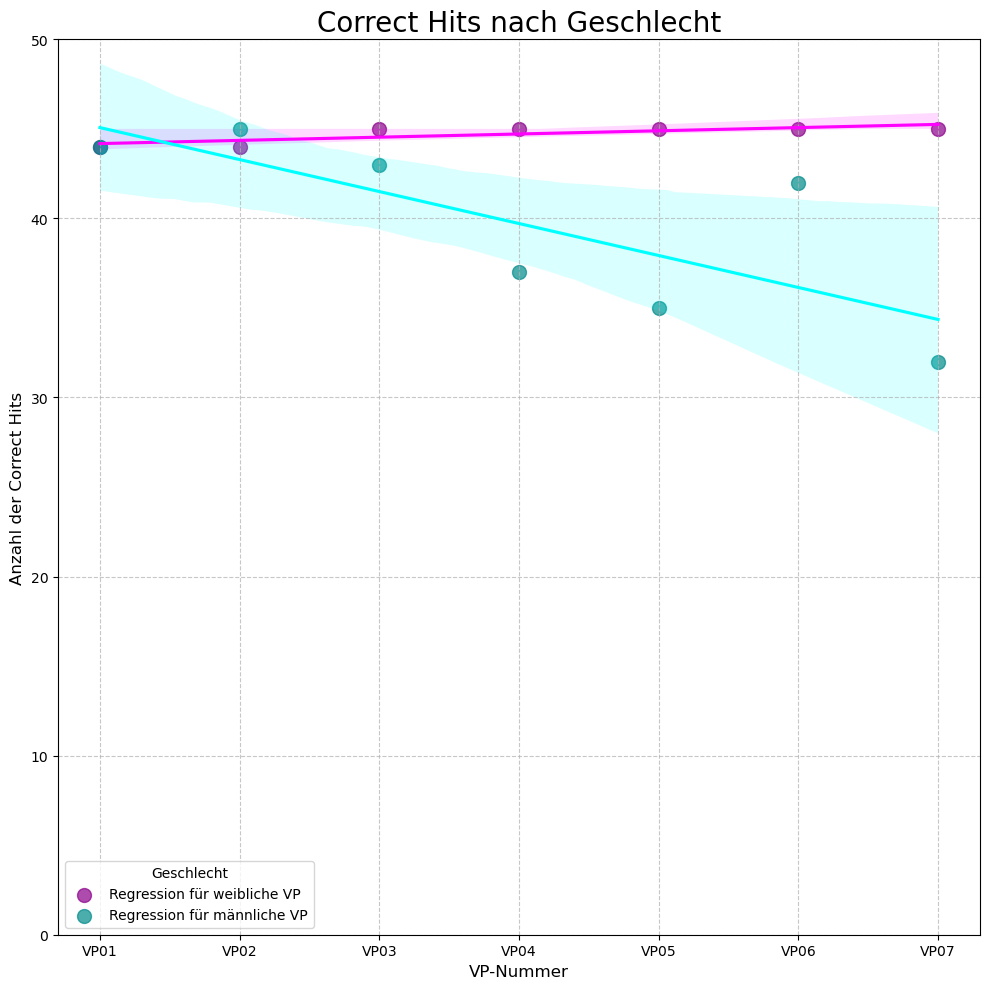

In [73]:
female_df = pd.DataFrame([
    {'vp_id': 'VP01', 'cor_hi': 44, 'fal_hits': 1, 'cor_miss': 13, 'fal_miss': 2},
    {'vp_id': 'VP02', 'cor_hi': 44, 'fal_hits': 1, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP03', 'cor_hi': 45, 'fal_hits': 0, 'cor_miss': 14, 'fal_miss': 1},
    {'vp_id': 'VP04', 'cor_hi': 45, 'fal_hits': 0, 'cor_miss': 14, 'fal_miss': 1},
    {'vp_id': 'VP05', 'cor_hi': 45, 'fal_hits': 0, 'cor_miss': 13, 'fal_miss': 2},
    {'vp_id': 'VP06', 'cor_hi': 45, 'fal_hits': 0, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP07', 'cor_hi': 45, 'fal_hits': 0, 'cor_miss': 13, 'fal_miss': 2},
])

male_df = pd.DataFrame([
    {'vp_id': 'VP01', 'cor_hit': 44, 'fal_hits': 1, 'cor_miss': 15, 'fal_miss': 0},
    {'vp_id': 'VP02', 'cor_hit': 45, 'fal_hits': 0, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP03', 'cor_hit': 43, 'fal_hits': 2, 'cor_miss': 12, 'fal_miss': 3},
    {'vp_id': 'VP04', 'cor_hit': 37, 'fal_hits': 8, 'cor_miss': 9, 'fal_miss': 6},
    {'vp_id': 'VP05', 'cor_hit': 35, 'fal_hits': 10, 'cor_miss': 11, 'fal_miss': 4},
    {'vp_id': 'VP06', 'cor_hit': 42, 'fal_hits': 3, 'cor_miss': 8, 'fal_miss': 7},
    {'vp_id': 'VP07', 'cor_hit': 32, 'fal_hits': 13, 'cor_miss': 7, 'fal_miss': 8},
])

# 'vp_id' in numerische Variable umschreiben (AI)
female_df['vp_id_num'] = [int(vp[2:]) for vp in female_df['vp_id']]  
male_df['vp_id_num'] = [int(vp[2:]) for vp in male_df['vp_id']]

plt.figure(figsize=(10, 10)) 
sns.regplot(x='vp_id_num', y='cor_hi', data=female_df, scatter_kws={'alpha':0.7, 's':100, 'color': 'darkmagenta'}, line_kws={'color':'magenta'},  label='Regression für weibliche VP')
sns.regplot(x='vp_id_num', y='cor_hit', data=male_df,  scatter_kws={'alpha':0.7, 's':100, 'color': 'darkcyan'},  line_kws={'color':'cyan'},  label='Regression für männliche VP')  

plt.title('Correct Hits nach Geschlecht', fontsize=20)
plt.xlabel('VP-Nummer', fontsize=12)
plt.ylabel('Anzahl der Correct Hits', fontsize=12)

# Set x-ticks to show original VP-IDs
plt.xticks(female_df['vp_id_num'], female_df['vp_id'])

plt.ylim(0, 50)

plt.grid(linestyle='--', alpha=0.7) 
plt.legend(title='Geschlecht', fontsize=10) 

plt.tight_layout()
plt.show()

#### Alter

In [19]:
print(combined_df['cor_hits'].corr(combined_df['age']))
print()
print(combined_df['fal_hits'].corr(combined_df['age']))
print()
print(combined_df['cor_miss'].corr(combined_df['age']))
print()
print(combined_df['fal_miss'].corr(combined_df['age']))

-0.21636816364547432

0.21636816364547432

-0.03284326724072504

0.03284326724072508


<Figure size 640x480 with 0 Axes>

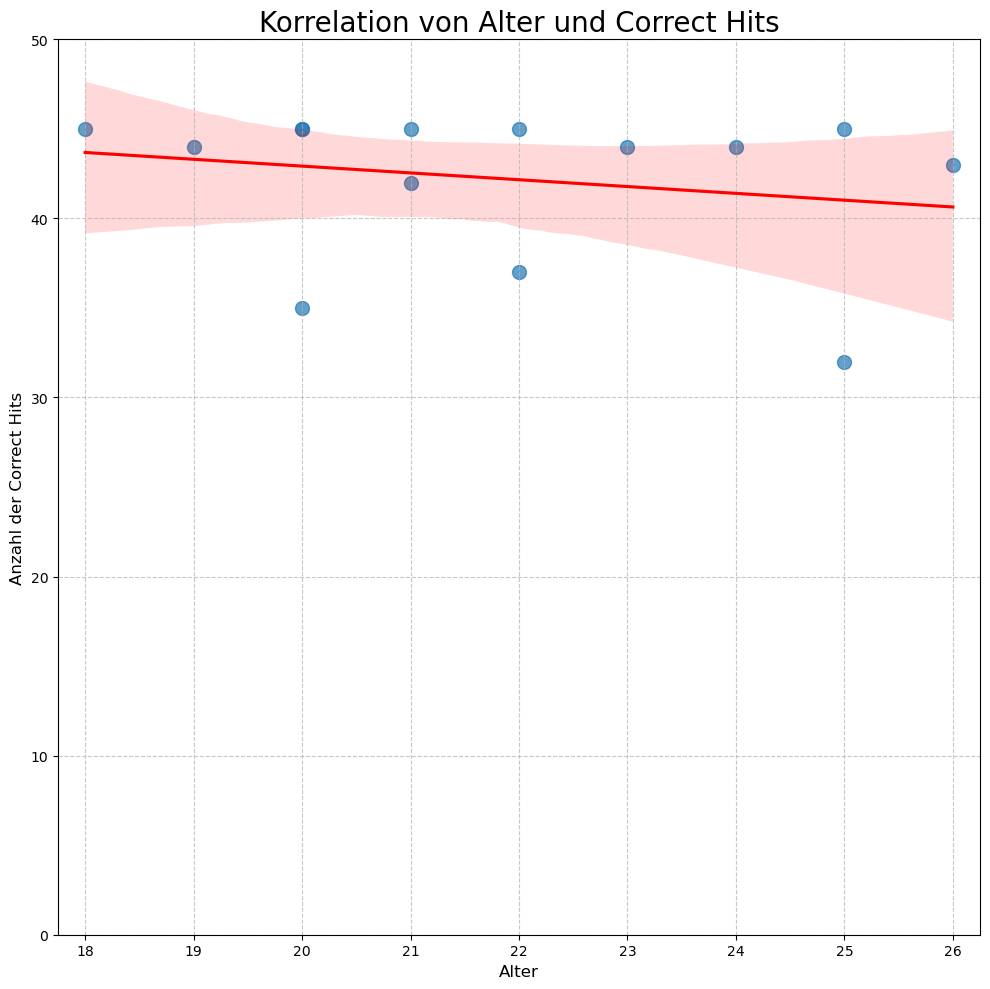

In [59]:
plt.figure()

plt.figure(figsize=(10,10))
sns.regplot(x='age', y='cor_hits', data=combined_df, scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':'red', 'label': 'Lineare Regression'})
# Weiß jemand warum zwar keine Fehlermeldung aufkommt, es aber auch keine Beschriftung gibt?

plt.title('Korrelation von Alter und Correct Hits', fontsize=20)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Anzahl der Correct Hits', fontsize=12)
plt.ylim(0, 50)
plt.xlim(17.75, 26.25)

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

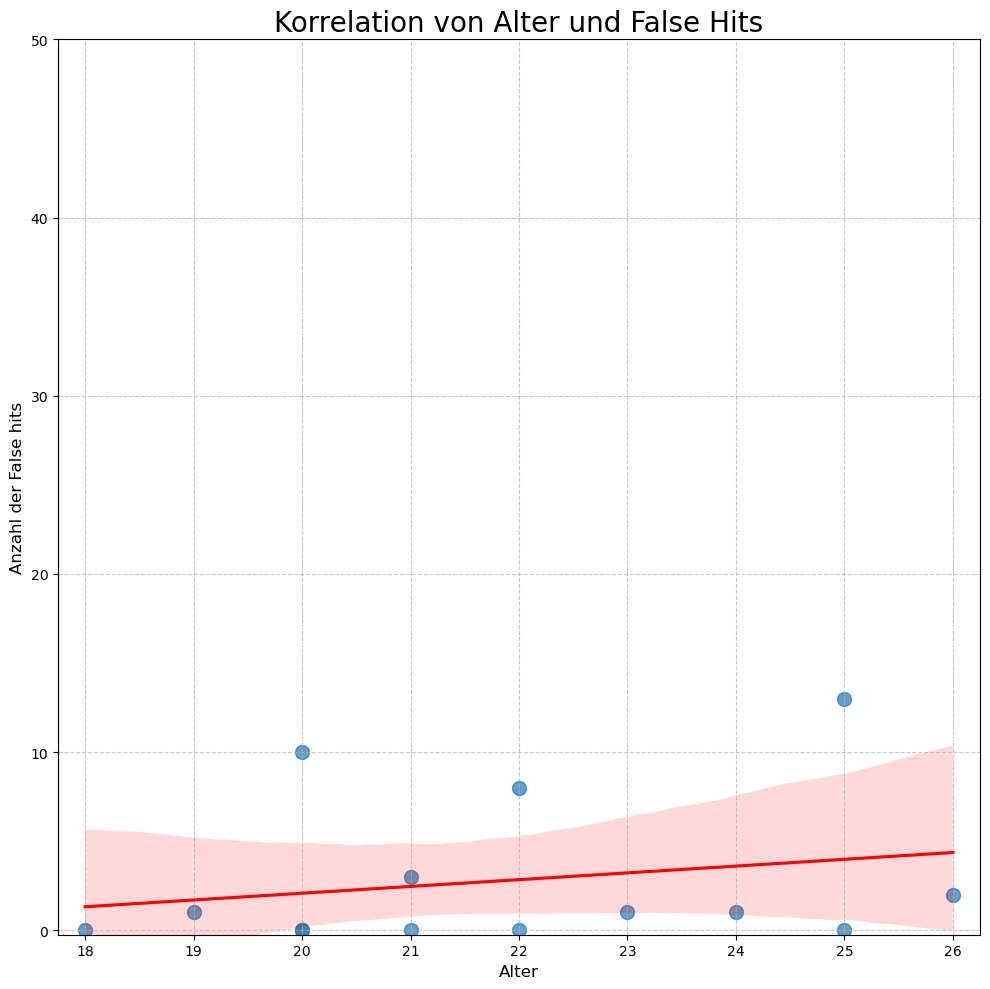

In [46]:
plt.figure()

plt.figure(figsize=(10,10))
sns.regplot(x='age', y='fal_hits', data=combined_df, scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':'red', 'label': 'Lineare Regression'})
# Weiß jemand warum zwar keine Fehlermeldung aufkommt, es aber auch keine Beschriftung gibt?

plt.title('Korrelation von Alter und False Hits', fontsize=20)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Anzahl der False Hits', fontsize=12)
plt.ylim(-0.25, 50)
plt.xlim(17.75, 26.25)

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

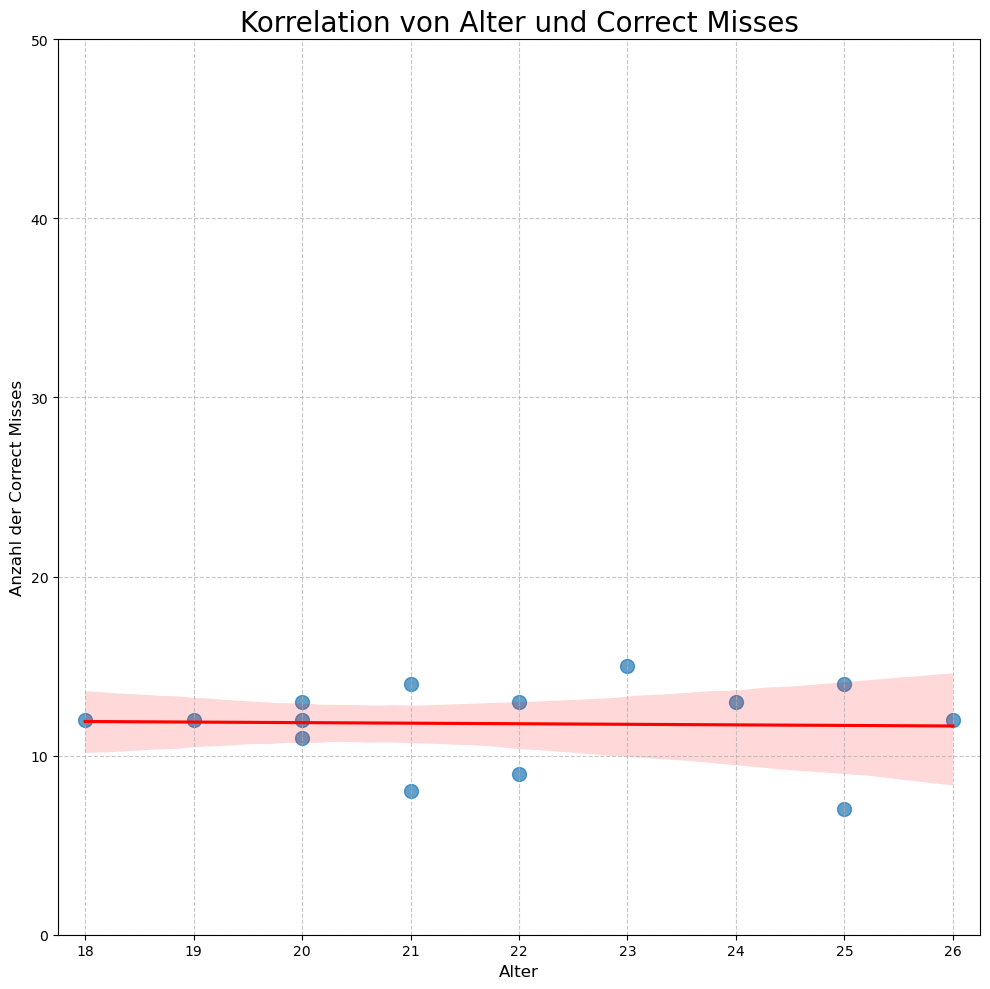

In [47]:
plt.figure()

plt.figure(figsize=(10,10))
sns.regplot(x='age', y='cor_miss', data=combined_df, scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':'red', 'label': 'Lineare Regression'})
# Weiß jemand warum zwar keine Fehlermeldung aufkommt, es aber auch keine Beschriftung gibt?

plt.title('Korrelation von Alter und Correct Misses', fontsize=20)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Anzahl der Correct Misses', fontsize=12)
plt.ylim(0, 50)
plt.xlim(17.75, 26.25)

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

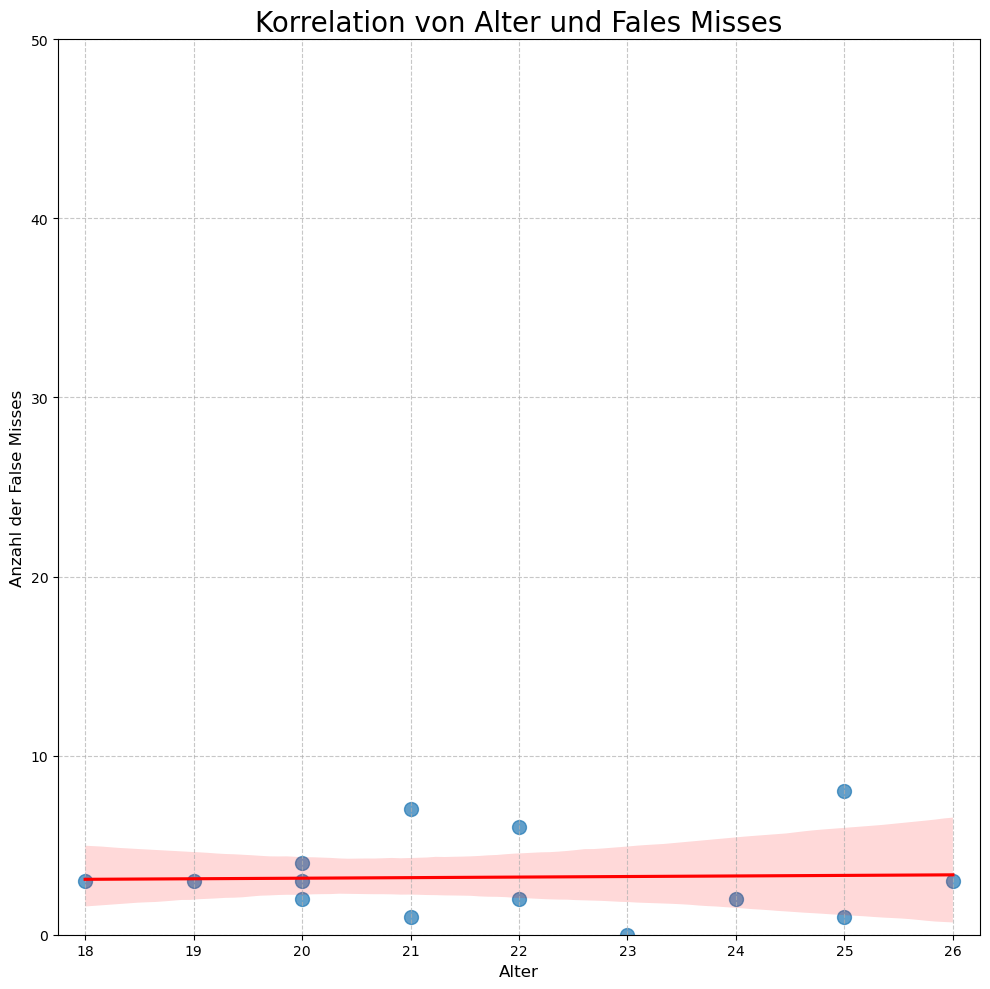

In [48]:
plt.figure()

plt.figure(figsize=(10,10))
sns.regplot(x='age', y='fal_miss', data=combined_df, scatter_kws={'alpha':0.7, 's':100}, line_kws={'color':'red', 'label': 'Lineare Regression'})
# Weiß jemand warum zwar keine Fehlermeldung aufkommt, es aber auch keine Beschriftung gibt?

plt.title('Korrelation von Alter und Fales Misses', fontsize=20)
plt.xlabel('Alter', fontsize=12)
plt.ylabel('Anzahl der False Misses', fontsize=12)
plt.ylim(0, 50)
plt.xlim(17.75, 26.25)

plt.grid(linestyle='--', alpha=0.7)
plt.tight_layout()